# Course 1 - Modul 2: Pengambilan Data (*Data Retrieval*) & Pembersihan Data (*Data Cleansing*)
**Mata Kuliah**: Data Mining  
**Identifikasi Progress**: Minggu 2 (`c1-m2`)  
**Format File**: Jupyter Lab Notebook (`.ipynb`)  
**Lingkup Materi**: Pengambilan data dari berkas (CSV, JSON), basis data SQL (SQLite `classic_rock.db`), basis data NoSQL (MongoDB), API/Cloud, pembersihan data (duplikat, *missing values*), dan deteksi *outliers* (visual, IQR matematis, residual-based).

---

## 🎯 Capaian Pembelajaran Minggu 2:
1. Mampu mengambil data dari berbagai sumber data terstruktur dan semi-terstruktur: berkas CSV, berkas JSON, basis data relasional SQL (menggunakan `sqlite3` dan `pandas.read_sql`), basis data non-relasional NoSQL (MongoDB sintaks), dan endpoint Web/API.
2. Menguasai parameter lanjutan pembacaan data: penanganan *delimiters*, *headers*, tipe data tanggal (*date parsing*), *type coercion*, dan streaming data besar via generator *chunks*.
3. Memahami pentingnya pembersihan data (*Data Cleansing*) dan prinsip *"Garbage-In, Garbage-Out"*.
4. Mampu menangani *missing values* secara sistematis (analisis pola kehilangan, strategi *drop* vs imputasi *mean*/*median*/*mode*, serta analisis dampaknya).
5. Menguasai deteksi *outliers* secara visual (Boxplot, Histogram, KDE), matematis (*Interquartile Range / IQR*), dan berbasis residual model regresi (*Standardized*, *Deleted*, dan *Studentized Residuals*).
6. Mengimplementasikan berbagai strategi penanganan *outliers* (penghapusan, winsorisasi/clipping, transformasi variabel, dan prediksi).


---
## 1. Setup Lingkungan & Import Library


In [1]:
import os
import sqlite3 as sq3
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi visualisasi
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)

print("Semua pustaka berhasil diimpor.")


Semua pustaka berhasil diimpor.


---
## 2. Pengambilan Data (*Data Retrieval*)

### 2.1. Membaca Berkas CSV (*Comma Separated Values*)
Berkas CSV menyimpan data tabular di mana setiap baris dipisahkan oleh karakter koma atau pemisah lainnya. Fungsi `pd.read_csv()` menyediakan berbagai parameter fleksibel:
- `sep` / `delimiter`: Karakter pemisah (misal `\t` untuk tab-separated values).
- `delim_whitespace`: Menangani pemisah spasi dengan panjang dinamis.
- `header`: Menentukan baris indeks yang menjadi nama kolom.
- `names`: Mendefinisikan nama kolom secara eksplisit.
- `na_values`: Daftar string yang harus dianggap sebagai *missing values* (misal `'NA'`, `'99'`, `'missing'`).


In [2]:
# Membaca berkas CSV standar (Iris Dataset)
file_path_csv = 'data/iris_data.csv'
data_iris = pd.read_csv(file_path_csv)

print("Bentuk Dataset (Baris, Kolom):", data_iris.shape)
print()
print("Lima Baris Pertama Data:")
data_iris.iloc[:5]


Bentuk Dataset (Baris, Kolom): (150, 5)

Lima Baris Pertama Data:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.6,3.5,1.5,0.4,setosa
1,5.1,3.6,1.5,0.1,setosa
2,4.8,3.7,1.6,0.2,setosa
3,5.3,3.2,1.6,0.2,setosa
4,5.0,3.4,1.7,0.1,setosa


#### Eksplorasi Parameter Khusus `read_csv`


In [3]:
# Contoh penggunaan parameter na_values, names, dan header
# Menentukan string tertentu yang harus dianggap sebagai NaN
sample_csv = pd.read_csv(
    file_path_csv,
    header=0,
    names=['panjang_sepal', 'lebar_sepal', 'panjang_petal', 'lebar_petal', 'spesies'],
    na_values=['NA', '99', 'unknown']
)

print("DataFrame dengan Nama Kolom Kustom:")
sample_csv.head(3)


DataFrame dengan Nama Kolom Kustom:


,panjang_sepal,lebar_sepal,panjang_petal,lebar_petal,spesies
0,5.6,3.5,1.5,0.4,setosa
1,5.1,3.6,1.5,0.1,setosa
2,4.8,3.7,1.6,0.2,setosa


---
### 2.2. Membaca & Menulis Berkas JSON (*JavaScript Object Notation*)
JSON merupakan format standar pertukaran data semi-terstruktur berbasis pasangan kunci-nilai (*key-value pairs*), sangat umum digunakan pada basis data NoSQL dan Web API.

Pandas menyediakan parameter `orient` untuk berbagai format struktur JSON:
- `'records'`: Daftar kamus baris demi baris `[{kolom -> nilai}, ...]`.
- `'split'`: Kamus dengan kunci `['columns', 'index', 'data']`.
- `'index'`: Kamus dengan kunci indeks `{indeks -> {kolom -> nilai}}`.
- `'columns'`: Kamus dengan kunci nama kolom `{kolom -> {indeks -> nilai}}`.


In [4]:
file_path_json = 'data/sample.json'

# Membaca berkas JSON ke dalam DataFrame
df_json = pd.read_json(file_path_json, orient='records')

print("Dimensi Data JSON:", df_json.shape)
print()
print("Tiga Baris Pertama:")
df_json.head(3)


Dimensi Data JSON: (20, 4)

Tiga Baris Pertama:


,customer_id,category,age,spend
0,CUST_0000,Tech,51,228.29
1,CUST_0001,Tech,44,272.89
2,CUST_0002,Home,28,557.74


In [5]:
# Menulis DataFrame kembali ke format JSON
output_json_path = 'data/output_export.json'
df_json.to_json(output_json_path, orient='records', indent=2)

print(f"Berkas berhasil diekspor ke: {output_json_path}")


Berkas berhasil diekspor ke: data/output_export.json


---
### 2.3. Pengambilan Data dari Basis Data Relasional SQL (SQLite)
Basis data relasional (RDBMS) mengorganisasi data dalam bentuk tabel dengan skema (*schema*) yang tetap dan terstruktur kaku.
- **Sistem RDBMS Populer**: SQLite, PostgreSQL, MySQL, Microsoft SQL Server, Oracle DB, IBM Db2, AWS Redshift.
- **Pustaka Python**: `sqlite3`, `SQLAlchemy`, `psycopg2` (PostgreSQL), `ibm_db` (IBM Db2).

Pada bagian ini, kita membuka koneksi ke basis data SQLite `data/classic_rock.db`, mengeksekusi kueri, dan memuat hasilnya langsung ke dalam Pandas DataFrame menggunakan `pd.read_sql()`.


In [6]:
# 1. Inisialisasi Jalur Database dan Pembuatan Koneksi
db_path = 'data/classic_rock.db'
con = sq3.connect(db_path)
print(f"Koneksi SQLite berhasil terhubung ke: {db_path}")

# 2. Kueri Dasar: Mengambil Semua Baris dari Tabel rock_songs
query_basic = "SELECT * FROM rock_songs"
df_rock = pd.read_sql(query_basic, con)

print(f"Total Baris Data Lagu: {len(df_rock)}")
print()
print("Lima Baris Pertama Tabel rock_songs:")
df_rock.head()


Koneksi SQLite berhasil terhubung ke: data/classic_rock.db
Total Baris Data Lagu: 161

Lima Baris Pertama Tabel rock_songs:


,Song_Clean,Artist,Release_Year,PlayCount
0,The Beatles Song 1,The Beatles,1967,4
1,The Beatles Song 2,The Beatles,1967,7
2,The Beatles Song 3,The Beatles,1967,6
3,The Beatles Song 4,The Beatles,1967,5
4,The Beatles Song 5,The Beatles,1967,7


#### Kueri Agregasi Kompleks SQL:
Menghitung jumlah lagu dan rata-rata pemutaran (*average play count*) per artis dan tahun rilis, diurutkan dari yang terbanyak.


In [7]:
# Kueri Agregasi dengan GROUP BY dan ORDER BY DESC
query_agg = """
SELECT 
    Artist, 
    Release_Year, 
    COUNT(*) AS Song_Count, 
    AVG(PlayCount) AS Average_Plays
FROM rock_songs
GROUP BY Artist, Release_Year
ORDER BY Song_Count DESC
"""

df_top_artists = pd.read_sql(query_agg, con)
print("Top 5 Kombinasi Artis & Tahun Rilis:")
df_top_artists.head()


Top 5 Kombinasi Artis & Tahun Rilis:


,Artist,Release_Year,Song_Count,Average_Plays
0,The Beatles,1967,23,5.782609
1,The Beatles,1969,14,6.642857
2,Led Zeppelin,1969,12,4.583333
3,Fleetwood Mac,1977,11,6.000000
4,The Rolling Stones,1969,11,4.818182


#### Parameter Lanjutan `pd.read_sql`: `coerce_float`, `parse_dates`, dan Streaming dengan `chunksize`
Ketika bekerja dengan kumpulan data sangat besar di memori terbatas, kita dapat menggunakan parameter `chunksize` yang mengembalikan objek *generator* (aliran data per batch).


In [8]:
# Menggunakan streaming chunksize=5 dengan date parsing
observation_generator = pd.read_sql(
    query_agg, 
    con, 
    coerce_float=True, 
    parse_dates=['Release_Year'], 
    chunksize=5
)

print("Streaming Hasil Kueri dalam Chunks (Ukuran 5 Baris per Iterasi):\n")
for index, chunk in enumerate(observation_generator):
    if index < 3: # Menampilkan 3 batch pertama
        print(f"--- Chunk Iterasi ke-{index} ---")
        display(chunk)
    else:
        break

# Menutup koneksi database setelah selesai
con.close()
print("Koneksi SQLite ditutup.")


Streaming Hasil Kueri dalam Chunks (Ukuran 5 Baris per Iterasi):

--- Chunk Iterasi ke-0 ---


,Artist,Release_Year,Song_Count,Average_Plays
0,The Beatles,1970-01-01 00:32:47,23,5.782609
1,The Beatles,1970-01-01 00:32:49,14,6.642857
2,Led Zeppelin,1970-01-01 00:32:49,12,4.583333
3,Fleetwood Mac,1970-01-01 00:32:57,11,6.000000
4,The Rolling Stones,1970-01-01 00:32:49,11,4.818182


--- Chunk Iterasi ke-1 ---


,Artist,Release_Year,Song_Count,Average_Plays
0,AC/DC,1970-01-01 00:33:00,10,7.800000
1,Led Zeppelin,1970-01-01 00:32:51,10,8.000000
2,The Rolling Stones,1970-01-01 00:32:52,10,6.400000
3,David Bowie,1970-01-01 00:32:52,9,5.888889
4,Eagles,1970-01-01 00:32:56,9,5.777778


--- Chunk Iterasi ke-2 ---


,Artist,Release_Year,Song_Count,Average_Plays
0,Pink Floyd,1970-01-01 00:32:53,9,7.000000
1,The Who,1970-01-01 00:32:51,9,4.555556
2,Black Sabbath,1970-01-01 00:32:50,8,4.750000
3,Deep Purple,1970-01-01 00:32:52,8,5.000000
4,Queen,1970-01-01 00:32:55,8,6.375000


Koneksi SQLite ditutup.


---
### 2.4. Arsitektur Basis Data NoSQL (*Non-Relational Databases*)
Basis data NoSQL menyimpan data tanpa skema kaku, sangat ideal untuk data berskala masif, semi-terstruktur, atau tidak terstruktur:
1. **Document Stores** (MongoDB, CouchDB): Menyimpan dokumen dalam format mirip JSON/BSON.
2. **Key-Value Stores** (Redis, DynamoDB): Menyimpan data berbasis pasangan kunci unik dan nilainya.
3. **Graph Databases** (Neo4j): Mengoptimalkan representasi relasi dan jaringan (misal: koneksi pertemanan LinkedIn).
4. **Wide-Column Stores** (Apache Cassandra, ScyllaDB): Mengelompokkan kolom ke dalam keluarga kolom (*column families*).

#### Sintaks Ekstraksi Data MongoDB ke Pandas (Pustaka `pymongo`):
```python
from pymongo import MongoClient

# 1. Membuka koneksi ke server MongoDB
client = MongoClient("mongodb://localhost:27017/")

# 2. Memilih basis data dan koleksi
db = client['nama_database']
koleksi = db['nama_koleksi']

# 3. Menjalankan kueri pencarian (filter kosong {} setara SELECT *)
cursor = koleksi.find({})

# 4. Mengubah cursor generator menjadi list of dictionaries, lalu ke DataFrame
df_nosql = pd.DataFrame(list(cursor))
```


---
### 2.5. Akses Data dari Web / API Publik
Kita dapat langsung mengunduh dataset publik dari URL internet secara langsung melalui `pd.read_csv()`.


In [9]:
# Mengakses dataset dari URL publik
url_data = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"

try:
    df_web = pd.read_csv(url_data)
    print("Berhasil mengambil data langsung dari Web URL. Dimensi:", df_web.shape)
    display(df_web.head(3))
except Exception as e:
    print("Koneksi internet tidak tersedia atau URL terhalang, menggunakan data lokal:", e)


Berhasil mengambil data langsung dari Web URL. Dimensi: (150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa


---
## 3. Pembersihan Data (*Data Cleansing*)

Prinsip utama dalam data mining adalah **"Garbage-in, Garbage-out"**: seberapa canggih pun algoritma machine learning yang digunakan, jika data yang diberikan kotor, model akan menghasilkan prediksi yang keliru dan menyesatkan.

### 3.1. Identifikasi & Penanganan Data Duplikat
Data duplikat dapat memberikan bobot berlebih (*over-representation*) pada sampel tertentu dan membiaskan model.


In [10]:
# Simulasi data dengan duplikasi
df_simulasi = pd.DataFrame({
    'id': [101, 102, 103, 103, 104, 105, 105],
    'nilai': [75, 80, 85, 85, 90, 95, 95]
})

print("Jumlah Baris Sebelum Dihapus:", len(df_simulasi))
print("Jumlah Baris Duplikat:", df_simulasi.duplicated().sum())

# Menghapus duplikasi
df_bersih = df_simulasi.drop_duplicates().reset_index(drop=True)
print("Jumlah Baris Setelah drop_duplicates():", len(df_bersih))
df_bersih


Jumlah Baris Sebelum Dihapus: 7
Jumlah Baris Duplikat: 2
Jumlah Baris Setelah drop_duplicates(): 5


,id,nilai
0,101,75
1,102,80
2,103,85
3,104,90
4,105,95


---
### 3.2. Penanganan Nilai Hilang (*Missing Values*)
Dalam data riil, nilai yang hilang dapat disebabkan oleh kegagalan sensor, penolakan responden survei, atau kesalahan integrasi sistem.

#### Perbandingan Strategi:
1. **Penghapusan (*Dropping Rows*)**:
   - *Kelebihan*: Tidak menambahkan asumsi buatan ke dalam data.
   - *Kekurangan*: Kehilangan informasi penting dan mengurangi ukuran sampel secara drastis jika banyak baris yang terkena.
2. **Imputasi Nilai (*Mean, Median, Mode*)**:
   - *Kelebihan*: Mempertahankan seluruh observasi baris.
   - *Kekurangan*: Mengurangi variansi alami data dan menambahkan ketidakpastian/asumsi bahwa data yang hilang serupa dengan rata-rata/median.


In [11]:
# Simulasi dataset dengan Missing Values
np.random.seed(42)
df_missing = pd.DataFrame({
    'Usia': [22, np.nan, 28, 35, np.nan, 45, 30, 26],
    'Pendapatan': [5000, 7500, np.nan, 12000, 8500, np.nan, 9000, 6200],
    'Kota': ['Jakarta', 'Bandung', 'Jakarta', np.nan, 'Surabaya', 'Jakarta', 'Bandung', 'Surabaya']
})

print("=== Deteksi Nilai Hilang per Kolom ===")
print(df_missing.isnull().sum())


=== Deteksi Nilai Hilang per Kolom ===
Usia          2
Pendapatan    2
Kota          1
dtype: int64


In [12]:
# Demonstrasi Imputasi:
# Usia diisi dengan Median (robust terhadap skewness)
# Pendapatan diisi dengan Mean
# Kota diisi dengan Mode (nilai terbanyak untuk data kategorikal)

df_imputed = df_missing.copy()
df_imputed['Usia'] = df_imputed['Usia'].fillna(df_imputed['Usia'].median())
df_imputed['Pendapatan'] = df_imputed['Pendapatan'].fillna(df_imputed['Pendapatan'].mean())
df_imputed['Kota'] = df_imputed['Kota'].fillna(df_imputed['Kota'].mode()[0])

print("=== DataFrame Setelah Imputasi Lengkap ===")
df_imputed.round(2)


=== DataFrame Setelah Imputasi Lengkap ===


,Usia,Pendapatan,Kota
0,22.0,5000.00,Jakarta
1,29.0,7500.00,Bandung
2,28.0,8033.33,Jakarta
3,35.0,12000.00,Jakarta
4,29.0,8500.00,Surabaya
5,45.0,8033.33,Jakarta
6,30.0,9000.00,Bandung
7,26.0,6200.00,Surabaya


---
## 4. Deteksi dan Penanganan *Outliers*

**Outlier** adalah observasi yang letaknya sangat jauh atau berbeda secara signifikan dari sebagian besar observasi lainnya dalam kumpulan data.
- Contoh dampak: Jika sebagian besar transaksi bernilai Rp10.000 - Rp50.000, dan ada satu transaksi anomali bernilai Rp3.000.000, maka rata-rata (*mean*) akan tertarik drastis menjadi ratusan ribu rupiah, merusak performa model yang berbasis jarak atau rata-rata.

### 4.1. Deteksi Visual Outliers
Menggunakan berkas `data/unemployment.csv` yang berisi data tingkat pengangguran bulanan.


In [13]:
df_unemp = pd.read_csv('data/unemployment.csv')
print("Struktur Data Unemployment:", df_unemp.shape)
df_unemp.head()


Struktur Data Unemployment: (156, 3)


,year,month,unemployment
0,2010,1,5.48
1,2010,2,4.36
2,2010,3,6.43
3,2010,4,5.03
4,2010,5,6.16


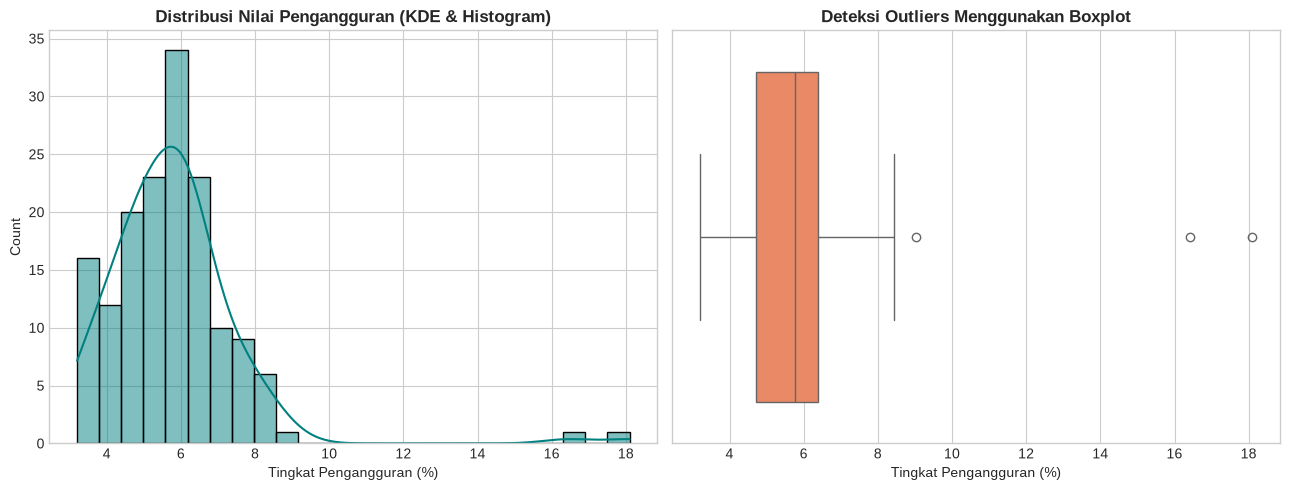

In [14]:
# Visualisasi Deteksi Outlier: Histogram, KDE, dan Boxplot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 1. Histogram & KDE Plot
sns.histplot(df_unemp['unemployment'], kde=True, bins=25, ax=axes[0], color='teal')
axes[0].set_title('Distribusi Nilai Pengangguran (KDE & Histogram)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tingkat Pengangguran (%)')

# 2. Boxplot
sns.boxplot(x=df_unemp['unemployment'], ax=axes[1], color='coral')
axes[1].set_title('Deteksi Outliers Menggunakan Boxplot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tingkat Pengangguran (%)')

plt.tight_layout()
plt.show()


---
### 4.2. Deteksi Matematis Berbasis IQR (*Interquartile Range*)

Secara matematis, batas ambang outlier Tukey dihitung dengan:
$$IQR = Q_{75} - Q_{25}$$
$$\text{Batas Bawah} = Q_{25} - 1.5 \times IQR$$
$$\text{Batas Atas} = Q_{75} + 1.5 \times IQR$$

Semua nilai di luar rentang $[\text{Batas Bawah}, \text{Batas Atas}]$ diklasifikasikan sebagai *outliers*.


In [15]:
# Perhitungan Kuartil dan IQR
q25 = np.percentile(df_unemp['unemployment'], 25)
q50 = np.percentile(df_unemp['unemployment'], 50)
q75 = np.percentile(df_unemp['unemployment'], 75)
iqr = q75 - q25

min_bound = q25 - 1.5 * iqr
max_bound = q75 + 1.5 * iqr

print(f"Kuartil 25 (Q1)  : {q25:.2f}")
print(f"Kuartil 50 (Q2)  : {q50:.2f} (Median)")
print(f"Kuartil 75 (Q3)  : {q75:.2f}")
print(f"Rentang IQR      : {iqr:.2f}")
print(f"Batas Bawah Outlier: {min_bound:.2f}")
print(f"Batas Atas Outlier : {max_bound:.2f}")

# Identifikasi data outlier menggunakan List Comprehension & Filtering
outliers_iqr = [x for x in df_unemp['unemployment'] if x > max_bound or x < min_bound]
print(f"\nJumlah Outlier Terdeteksi: {len(outliers_iqr)}")
print(f"Nilai-nilai Outlier: {outliers_iqr}")


Kuartil 25 (Q1)  : 4.72
Kuartil 50 (Q2)  : 5.75 (Median)
Kuartil 75 (Q3)  : 6.39
Rentang IQR      : 1.67
Batas Bawah Outlier: 2.21
Batas Atas Outlier : 8.89

Jumlah Outlier Terdeteksi: 3
Nilai-nilai Outlier: [9.03, 16.43, 18.1]


---
### 4.3. Deteksi Outlier Berbasis Residual Model (*Residual-Based Detection*)

Residual adalah selisih antara nilai riil observasi dengan nilai yang diprediksi oleh model:
$$e_i = y_i - \hat{y}_i$$

Dalam statistika lanjutan, kita dapat menggunakan:
1. **Standardized Residuals**: Residual dibagi dengan estimasi standar error residual ($e_i / s_e$). Nilai di luar rentang $[-3, +3]$ umumnya diidentifikasi sebagai outlier.
2. **Deleted Residuals (Leave-One-Out)**: Menghitung residual observasi ke-$i$ ketika model dilatih tanpa menyertakan observasi ke-$i$ tersebut.
3. **Studentized Residuals (Externally Studentized)**: Residual terhapus yang distandarkan terhadap variansi model tanpa titik tersebut.


In [16]:
# Demonstrasi Deteksi Berbasis Residual Model
from scipy import stats

x = np.arange(len(df_unemp))
y = df_unemp['unemployment'].values

# Fitting regresi linear sederhana (Ordinary Least Squares)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
y_pred = intercept + slope * x

# Menghitung Residual Mentah
residuals = y - y_pred

# Menghitung Standardized Residuals
residual_std = np.std(residuals)
standardized_residuals = residuals / residual_std

# Identifikasi Observasi dengan |Standardized Residual| > 3
outlier_idx_residual = np.where(np.abs(standardized_residuals) > 3)[0]
print(f"Indeks Outlier Berdasarkan Residual (> 3 Std): {outlier_idx_residual}")
print(f"Nilai Outlier: {y[outlier_idx_residual]}")


Indeks Outlier Berdasarkan Residual (> 3 Std): [123 124]
Nilai Outlier: [16.43 18.1 ]


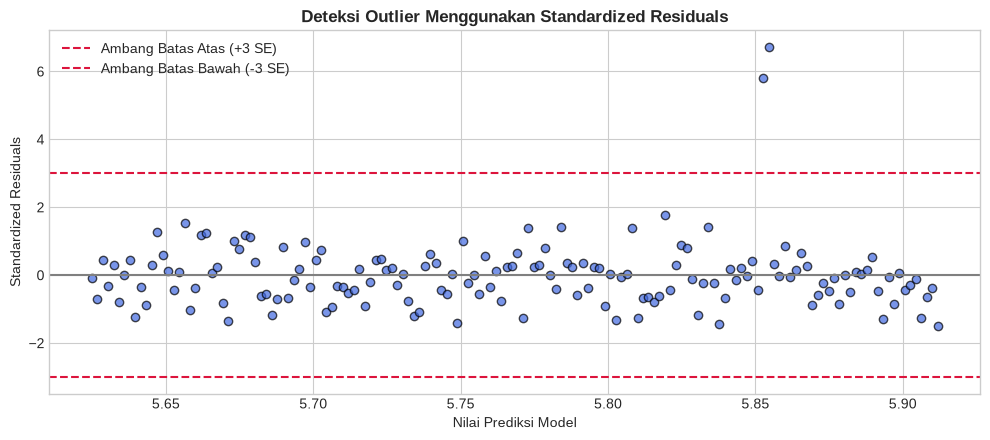

In [17]:
# Plot Residual vs Nilai Prediksi
plt.figure(figsize=(10, 4.5))
plt.scatter(y_pred, standardized_residuals, color='royalblue', alpha=0.7, edgecolors='k')
plt.axhline(3, color='crimson', linestyle='--', label='Ambang Batas Atas (+3 SE)')
plt.axhline(-3, color='crimson', linestyle='--', label='Ambang Batas Bawah (-3 SE)')
plt.axhline(0, color='gray', linestyle='-')
plt.title('Deteksi Outlier Menggunakan Standardized Residuals', fontsize=12, fontweight='bold')
plt.xlabel('Nilai Prediksi Model')
plt.ylabel('Standardized Residuals')
plt.legend()
plt.tight_layout()
plt.show()


---
### 4.4. Strategi Penanganan Outlier

Terdapat 5 pendekatan utama dalam menangani outlier:
1. **Menghapus (*Drop Outliers*)**: Menghilangkan baris yang mengandung anomali (cocok jika anomali adalah murni *data entry error*).
2. **Mengubah Nilai (*Winsorizing / Clipping*)**: Membatasi nilai ekstrim agar tepat berada pada batas atas atau batas bawah IQR.
3. **Transformasi Variabel**: Menerapkan transformasi logaritmik atau Box-Cox untuk memperkecil rentang skala data ekstrim.
4. **Prediksi / Imputasi**: Memprediksi nilai yang seharusnya menggunakan model regresi berdasarkan fitur lainnya.
5. **Mempertahankan Nilai**: Menggunakan model machine learning yang resisten terhadap outlier (misal: *Random Forest*, *Gradient Boosting*, atau *Robust Huber Loss*).


In [18]:
# Demonstrasi Strategi 2: Winsorizing / Clipping
df_clipped = df_unemp.copy()
df_clipped['unemployment_clipped'] = np.clip(
    df_clipped['unemployment'], 
    a_min=min_bound, 
    a_max=max_bound
)

print(f"Nilai Maksimum Asli    : {df_unemp['unemployment'].max():.2f}")
print(f"Nilai Maksimum Clipped : {df_clipped['unemployment_clipped'].max():.2f}")


Nilai Maksimum Asli    : 18.10
Nilai Maksimum Clipped : 8.89


---
## 5. Kesimpulan & Rencana Progress Minggu 3

### 📝 Kesimpulan Minggu 2:
- Berhasil mengekstraksi data dari berkas CSV, berkas JSON, basis data relasional SQLite `classic_rock.db`, serta memahami alur query MongoDB dan Web API.
- Mempraktekkan kueri agregasi SQL dan streaming data batch menggunakan `chunksize` pada dataset musik rock.
- Menguasai identifikasi data duplikat dan pemulihan *missing values* melalui pendekatan drop dan imputasi.
- Mengimplementasikan deteksi *outlier* melalui tiga sudut pandang: visualisasi, matematis IQR, dan residual regresi, serta memahami 5 strategi penanganannya.

### 🚀 Roadmap Minggu 3 (`c1-m3`):
Pada modul berikutnya, kita akan mendalami:
1. **Exploratory Data Analysis (EDA)**: Teknik ringkasan statistik dan stratified sampling.
2. **Visualisasi Tingkat Lanjut**: Seaborn Pairplot, Hexbin joint plot, dan FacetGrid.
3. **Rekayasa Fitur & Transformasi Variabel**: Transformasi Log, Box-Cox, dan Polinomial.
4. **Encoding & Scaling**: One-Hot Encoding, Ordinal Encoding, StandardScaler, MinMaxScaler, dan RobustScaler.
